## NB3
## Objective

The goal of this notebook is to build and evaluate machine learning models to predict customer churn using engineered behavioral features, and identify key drivers of churn.

## Import the libraries

In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, f1_score, recall_score

## Load the dataset


In [2]:
df = pd.read_csv("C:/Projects/09_Customer_churn_predictor/data/final_churn_dataset.csv")
df.head()

,CustomerID,Frequency,TotalQuantity,Monetary,LastPurchase,Recency,Churn,AvgOrderValue,PurchaseIntensity,CustomerLifetime
0,12346.0,1,74215,77183.60,2011-01-18 10:01:00,325,1,77183.600000,0.003067,325
1,12347.0,7,2458,4310.00,2011-12-07 15:52:00,1,0,615.714286,3.500000,366
2,12348.0,4,2341,1797.24,2011-09-25 13:13:00,74,0,449.310000,0.053333,357
3,12349.0,1,631,1757.55,2011-11-21 09:51:00,18,0,1757.550000,0.052632,18
4,12350.0,1,197,334.40,2011-02-02 16:01:00,309,1,334.400000,0.003226,309


## Check data

In [4]:
df.shape

(4338, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         4338 non-null   float64
 1   Frequency          4338 non-null   int64  
 2   TotalQuantity      4338 non-null   int64  
 3   Monetary           4338 non-null   float64
 4   LastPurchase       4338 non-null   object 
 5   Recency            4338 non-null   int64  
 6   Churn              4338 non-null   int64  
 7   AvgOrderValue      4338 non-null   float64
 8   PurchaseIntensity  4338 non-null   float64
 9   CustomerLifetime   4338 non-null   int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 339.0+ KB


In [6]:
df.isnull().sum()

CustomerID           0
Frequency            0
TotalQuantity        0
Monetary             0
LastPurchase         0
Recency              0
Churn                0
AvgOrderValue        0
PurchaseIntensity    0
CustomerLifetime     0
dtype: int64

## Define Features and Target [Remove bad columns]

In [36]:
X = df.drop(columns=["Churn", "CustomerID", "LastPurchase", "Recency"])
y = df["Churn"]

In [37]:
X.dtypes

Frequency              int64
TotalQuantity          int64
Monetary             float64
AvgOrderValue        float64
PurchaseIntensity    float64
CustomerLifetime       int64
dtype: object

## Train/Test Split

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling (for logistic Regression)

In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1 - Logistic Regression

In [41]:
# Train the model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [42]:
# predict
y_pred_lr = lr.predict(X_test_scaled)

In [43]:
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Accuracy: 0.869815668202765
Precision: 0.7761904761904762
Recall: 0.7117903930131004
F1 Score: 0.7425968109339408


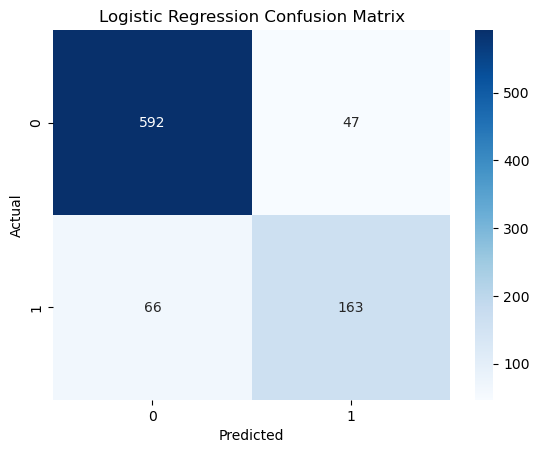

In [44]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model 2: Random Forest (Strong Model)

In [45]:
# Train the model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [46]:
# Predict
y_pred_rf = rf.predict(X_test)

In [47]:
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.9942396313364056
Precision: 0.995575221238938
Recall: 0.982532751091703
F1 Score: 0.989010989010989


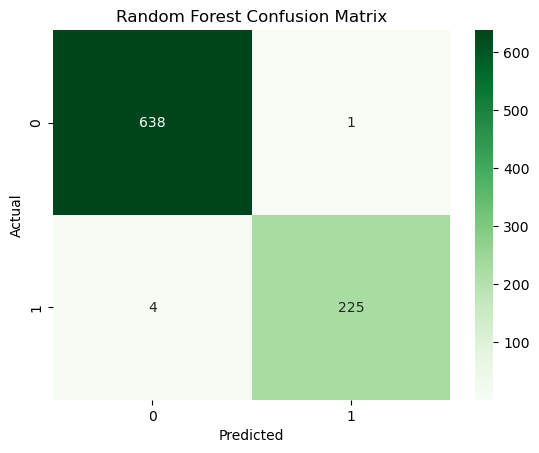

In [48]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Feature Importance

In [49]:
importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

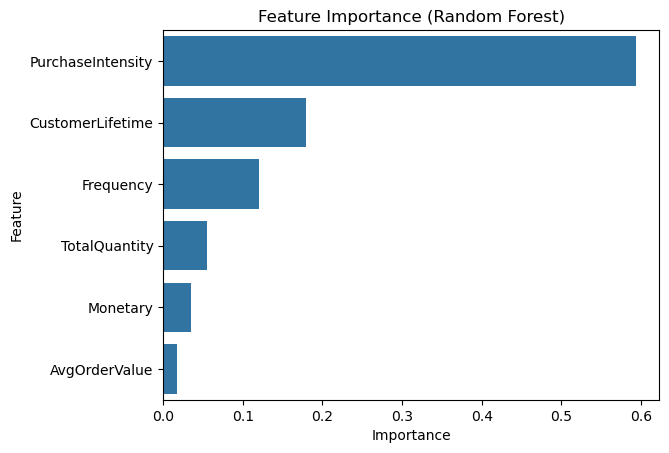

In [50]:
## Plot importance
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance (Random Forest)")
plt.show()

## Model Insights

The Random Forest model outperformed Logistic Regression in capturing nonlinear relationships in customer behavior.

Recency emerged as one of the most important features, confirming that customer inactivity is the strongest indicator of churn. Frequency and Purchase Intensity also played key roles, showing that more engaged customers are less likely to churn.

These results align with business expectations and validate the effectiveness of behavioral features for churn prediction.

# Compare Models

In [51]:
# Summary Tables
results = pd.DataFrame({
    "Model" : ["Logistic Regression", "Random Forest"],
    "Accuracy" : [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision" : [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall" : [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score" : [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.869816,0.776190,0.711790,0.742597
1,Random Forest,0.994240,0.995575,0.982533,0.989011


## Conclusion

This project successfully built a churn prediction system using customer behavioral data. The results show that recency, frequency, and purchase intensity are strong predictors of churn.

The Random Forest model achieved better performance, demonstrating the importance of capturing nonlinear patterns in customer behavior.

This system can help businesses identify at-risk customers early and take proactive retention actions.

## Save the models

In [52]:
import joblib
joblib.dump(rf,"C:/Projects/09_Customer_churn_predictor/notebooks/models/random_forest_model.pkl")
joblib.dump(rf,"C:/Projects/09_Customer_churn_predictor/notebooks/models/scaler.pkl")

['C:/Projects/09_Customer_churn_predictor/notebooks/models/scaler.pkl']